In [1]:
import os
import sys
import pathlib
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from lcsolver import tools
from lcsolver import solve

In [3]:
# create bath

# chain size
ns = 300
# on-site energies
e = [1.0]*ns
# hoppings between sites
h = [0.05]*(ns-1)

In [4]:
# discretize the bath: apply the lightcone method
bth = solve.bath.from_chain(chain = (e, h), rel_tol = 10**(-5), ring_size = 5, t_max = 500)

In [5]:
# save the bath
bth.save_to_file("bath.1")

In [6]:
# load from file
bth1 = solve.bath.load_from_file("bath.1")

In [7]:
# open system model
j = 0.5
top = tools.quantum_top(j)

# Hamiltonian for the free motion of spin
def Hs(t):
    return  0.5 * (2 * top.j_z + top.eye) + 2 * top.j_x * 0.1 * np.cos(t)

In [8]:
# coupling to the bath
def Vs(t):
    return 0.05 * top.j_m

In [9]:
## define the impurity problem

pr = solve.problem()
pr.set_impurity(Hs) # impurity Hamiltonian

pr.add_bath(bth1, Vs) # bath and coupling 

pr.add_impurity_observable("n", 0.5 * (2 * top.j_z + top.eye)) # what observables to compute

pr.compute_probs = False # save probabilities of trajectories and calculate entropy
pr.compute_dmatrices = False

# compute the sparse matrix for Fock space truncated on the level of max_num_quanta
pr.construct_model(max_num_quanta = 5)

In [10]:
# solve the problem
res = pr.solve(cfrom = 1, cto = 5, csize = 1, maxcores = 5, tmax = 200.0, fout = 'results.1')

Wellcome to lightcone impurity solver version 04.10.2023-23.56
Will compute  5  trajectories
on max  5  CPU cores
Will save results into  results.1
Will simulate up to time 200.0
submitting jobs to pool ...
running chunk  1 : m_max =  5 , dim =  504  ... 
running chunk  2 : m_max =  5 , dim =  504  ... 
running chunk  3 : m_max =  5 , dim =  504  ... 
running chunk  4 : m_max =  5 , dim =  504  ... 
running chunk  5 : m_max =  5 , dim =  504  ... 
 ... chunk  2  execution time:  38.247551918029785  sec
finished job  1  out of  5
 ... chunk  1  execution time:  39.04035997390747  sec
finished job  2  out of  5
 ... chunk  3  execution time:  38.94866490364075  sec
finished job  3  out of  5
 ... chunk  4  execution time:  39.328368186950684  sec
finished job  4  out of  5
 ... chunk  5  execution time:  39.07841372489929  sec
finished job  5  out of  5

Done!


/home/evgenii/condmat/lcsolver/main/lcsolver/conda-env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/evgenii/condmat/lcsolver/main/lcsolver/conda-env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


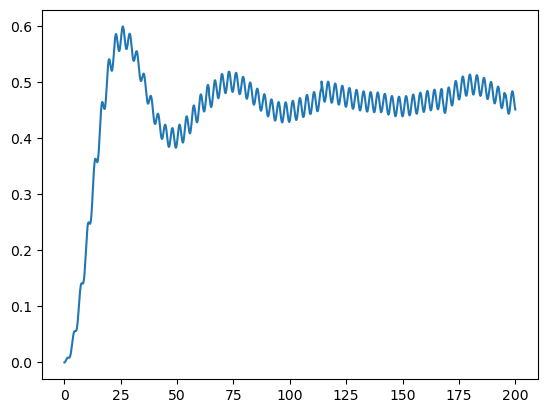

In [11]:
# plot observable
plt.plot(res.t, res['n'])